# Comparación de Ángulos de Rodilla — Izquierda vs Derecha
**Archivo analizado:** `slice_pinpoint_135_landmarks.csv`

Visualización de la trayectoria angular de ambas rodillas con los 4 instantes clave del saque marcados:
- 🟢 `start_f` — Posición inicial erguida
- 🔴 `min_f`   — Máxima flexión (posición de trofeo)
- 🔵 `max_f`   — Máxima extensión (despegue)
- 🟠 `target_f` — Punto objetivo (32.5% del arco min→max)

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import os

sys.path.append(os.path.abspath(".."))

from geometry import calculate_angle
from event_detector import calculate_knee_frames

CSV_PATH = Path(r"D:\desk\Results_Mediapipe\data_csv\slice_pinpoint_135_landmarks.csv")

In [6]:
df = pd.read_csv(CSV_PATH)

start_f, min_f, max_f, target_f, left_angles = calculate_knee_frames(df)

print(f"Archivo  : {CSV_PATH.stem}")
print(f"Frames totales : {len(df)}")
print()
print(f"  start_f  = frame {start_f:>3}  → ángulo izq: {left_angles[start_f]:.1f}°")
print(f"  min_f    = frame {min_f:>3}  → ángulo izq: {left_angles[min_f]:.1f}°")
print(f"  max_f    = frame {max_f:>3}  → ángulo izq: {left_angles[max_f]:.1f}°")
print(f"  target_f = frame {target_f:>3}  → ángulo izq: {left_angles[target_f]:.1f}°")
print()
print(f"  ROM (max-min) = {left_angles[max_f] - left_angles[min_f]:.1f}°")

Archivo  : slice_pinpoint_135_landmarks
Frames totales : 684

  start_f  = frame 358  → ángulo izq: nan°
  min_f    = frame 386  → ángulo izq: 127.6°
  max_f    = frame 515  → ángulo izq: 180.0°
  target_f = frame 427  → ángulo izq: 165.8°

  ROM (max-min) = 52.3°


In [7]:
import numpy as np
import pandas as pd

def get_right_knee_angles_series(df):
    """Calcula el ángulo de la rodilla DERECHA (cadera-rodilla-tobillo) para cada frame."""
    return [
        calculate_angle(
            [df.loc[i, 'RIGHT_HIP_x'],   df.loc[i, 'RIGHT_HIP_y']],
            [df.loc[i, 'RIGHT_KNEE_x'],  df.loc[i, 'RIGHT_KNEE_y']],
            [df.loc[i, 'RIGHT_ANKLE_x'], df.loc[i, 'RIGHT_ANKLE_y']]
        )
        for i in range(len(df))
    ]

right_angles_raw = get_right_knee_angles_series(df)
left_angles_raw  = list(left_angles)   # ya calculado por calculate_knee_frames

# Interpolación lineal solo para visualización — los NaN son gaps de tracking > 10 frames
left_angles  = pd.Series(left_angles_raw).interpolate(method='linear').fillna(method='bfill').fillna(method='ffill').tolist()
right_angles = pd.Series(right_angles_raw).interpolate(method='linear').fillna(method='bfill').fillna(method='ffill').tolist()

nan_left  = sum(1 for v in left_angles_raw  if np.isnan(v))
nan_right = sum(1 for v in right_angles_raw if np.isnan(v))
print(f"Frames con NaN (gaps de tracking no interpolados en cleaning):")
print(f"  Rodilla izquierda: {nan_left} frames")
print(f"  Rodilla derecha:   {nan_right} frames")

Frames con NaN (gaps de tracking no interpolados en cleaning):
  Rodilla izquierda: 83 frames
  Rodilla derecha:   0 frames


C:\Users\david\AppData\Local\Temp\ipykernel_1916\3886324755.py:19: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  left_angles  = pd.Series(left_angles_raw).interpolate(method='linear').fillna(method='bfill').fillna(method='ffill').tolist()
C:\Users\david\AppData\Local\Temp\ipykernel_1916\3886324755.py:20: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  right_angles = pd.Series(right_angles_raw).interpolate(method='linear').fillna(method='bfill').fillna(method='ffill').tolist()


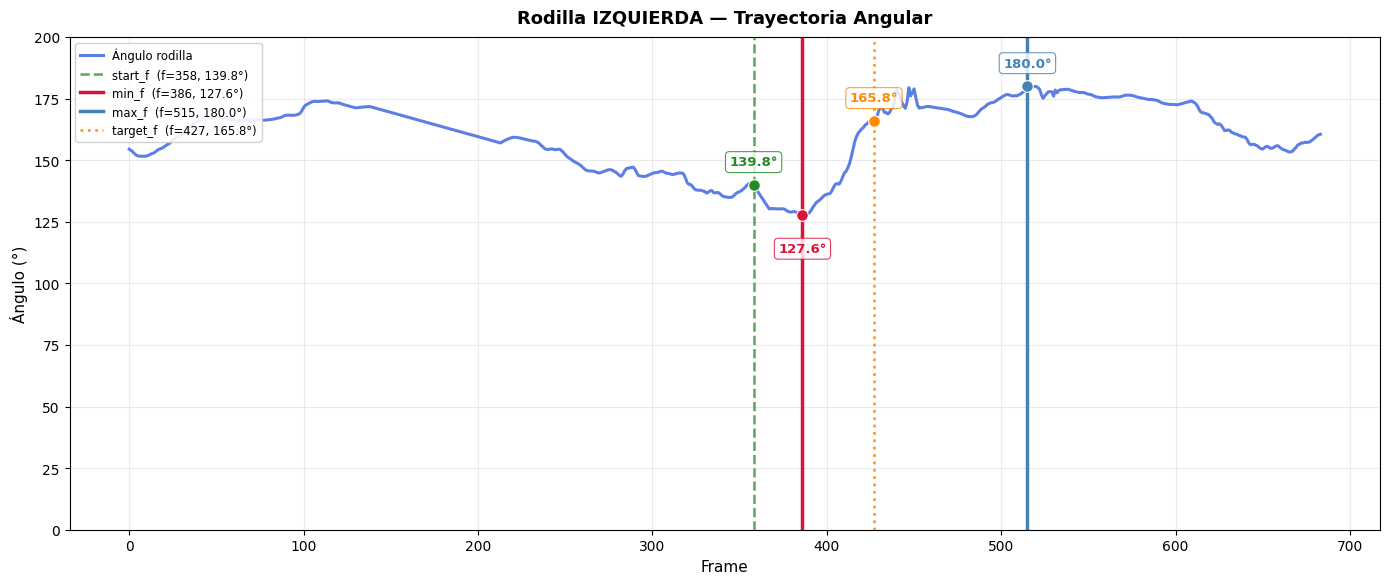

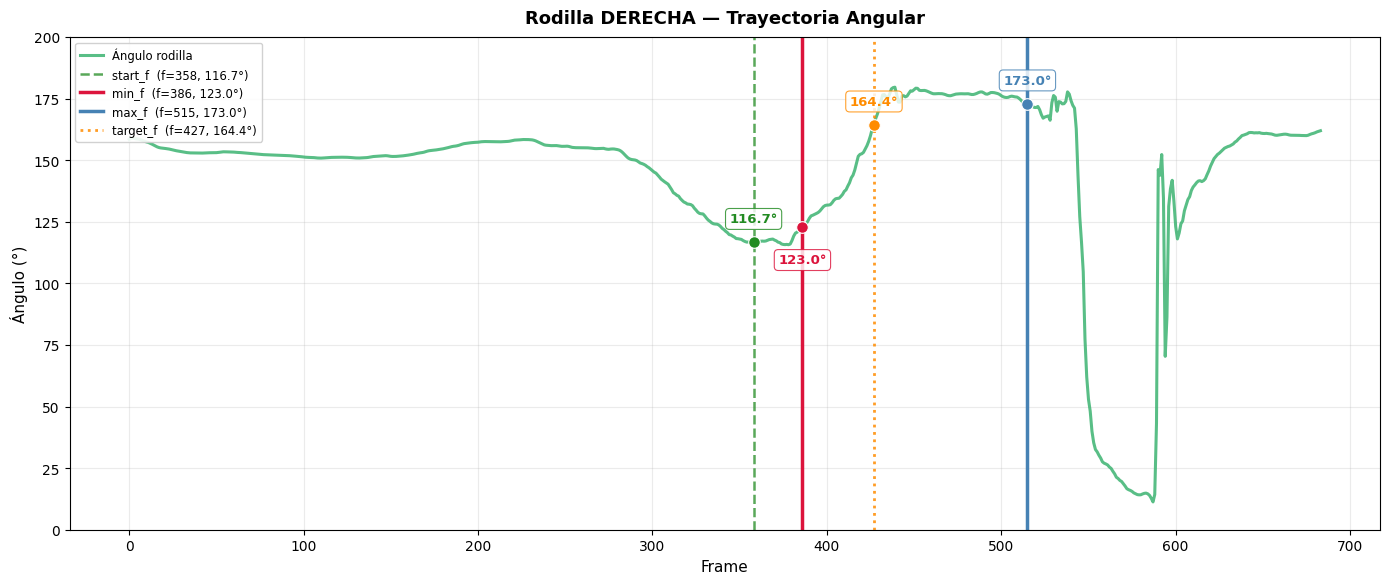

In [8]:
# --- Configuración visual de los 4 frames clave ---
KEY_FRAMES = [
    ('start_f',  start_f,  'forestgreen', '--', 1.8, 0.75, +8),
    ('min_f',    min_f,    'crimson',     '-',  2.5, 1.00, -15),
    ('max_f',    max_f,    'steelblue',   '-',  2.5, 1.00, +8),
    ('target_f', target_f, 'darkorange',  ':',  2.0, 0.85, +8),
]
# columnas: (nombre, frame, color, linestyle, linewidth, alpha, text_offset_y)


def draw_knee_plot(ax, angles, side_title, key_frames, line_color):
    """Dibuja la curva de ángulos de rodilla con los 4 instantes clave marcados."""

    ax.plot(angles, color=line_color, linewidth=2.2, alpha=0.85, label='Ángulo rodilla')

    for name, frame, color, ls, lw, alpha, y_off in key_frames:
        val = angles[frame]

        ax.axvline(x=frame, color=color, linestyle=ls, linewidth=lw,
                   alpha=alpha, label=f'{name}  (f={frame}, {val:.1f}°)')

        ax.scatter(frame, val, color=color, s=70, zorder=6,
                   edgecolors='white', linewidths=0.8)

        ax.text(
            frame, val + y_off,
            f"{val:.1f}°",
            color=color, fontweight='bold', ha='center', fontsize=9.5,
            bbox=dict(facecolor='white', alpha=0.82, edgecolor=color,
                      linewidth=0.8, boxstyle='round,pad=0.3')
        )

    ax.set_title(side_title, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel("Frame", fontsize=11)
    ax.set_ylabel("Ángulo (°)", fontsize=11)
    ax.set_ylim(0, 200)
    ax.grid(True, alpha=0.25)
    ax.legend(loc='upper left', fontsize='small', framealpha=0.9)


# --- Figura 1: Rodilla IZQUIERDA ---
fig1, ax1 = plt.subplots(figsize=(14, 6))
draw_knee_plot(ax1, left_angles, "Rodilla IZQUIERDA — Trayectoria Angular", KEY_FRAMES, 'royalblue')
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig("knee_left_angles.png", dpi=150, bbox_inches='tight')
plt.show()

# --- Figura 2: Rodilla DERECHA ---
fig2, ax2 = plt.subplots(figsize=(14, 6))
draw_knee_plot(ax2, right_angles, "Rodilla DERECHA — Trayectoria Angular", KEY_FRAMES, 'mediumseagreen')
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.savefig("knee_right_angles.png", dpi=150, bbox_inches='tight')
plt.show()